# 4_01 — The first cleavage: where it falls and what it costs

## Scope

The first event of the process needs no simulation. Competing exponential
clocks give the probability of each candidate cleavage as its share of the
total hazard, and the expected waiting time as the reciprocal of that hazard.
Both are exact.

This notebook computes that landscape for a sample of antimicrobial peptides,
under three weightings of the panel, and pairs each candidate cut with what it
would cost in activity.

## The three weightings

| Variant | Weight $w_\pi$ | Question it answers |
| --- | --- | --- |
| `uniform` | one | what the specificity matrices say on their own |
| `concentration` | circulating amount | what they say once abundance is accounted for |
| `concentration_only` | circulating amount, score switched off | whether specificity adds anything over abundance |

The third is the control. If it orders peptides the way `concentration` does,
then the specificity model is decoration and the result is an abundance
ranking wearing a matrix.

## The cost of a cut

A cut replaces the parent by two fragments. Both are contiguous, so both have a
predicted MIC in the precomputed table, and the mixture is summarised by the
potency sum $\psi = \sum_i C_i/\mathrm{MIC}_i$ of
`helpers.activity`. The cost of a cut is the drop in $\psi$ it causes, in
two-fold dilution steps.

## What the time axis means here

`3_01` fitted the global offset that turns the hazard into minutes, and found
that the modelled hazard does **not** order measured degradation rates: peptide
length alone predicts them better. The expected waiting times below therefore
carry the calibrated unit but not a demonstrated rate, and are labelled
provisional throughout. The **relative** ordering of cut positions within one
peptide does not depend on that constant and is unaffected.

## Execution contract

**Inputs:** `results/2_07_model_panel.csv`; `results/3_01_time_axis_calibration.csv`; `data/merops/34_homo_sapiens/matrices_logprob.npy`; `data/reference/human_proteome/composition.json`; `data/peptides_data/peptides_mic/peptides_apex.csv`; `data/peptides_data/peptides_mic/dbaasp_fragments_mic.csv`.

**Outputs:** `results/4_01_single_cut_landscape.csv`; `results/4_01_dominant_proteases.csv`.

**Depends on:** `2_07`, `3_01`.

**Boundary:** A computed first-cut landscape does not establish a measured MIC time course.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.activity import potency_sum
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    Fragment,
    ProteaseKinetics,
    first_cut_distribution,
    fragment_events,
    hazard_concentration,
    load_amino_acid_background,
    load_protease_panel,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
MIC_COLUMN = "A. baumannii ATCC 19606"
FRAGMENT_MIC_COLUMN = f"mic_{MIC_COLUMN}"
SCORE_SLOPE = 0.404 * np.log(10.0)
N_PROBE_PEPTIDES = 300
# Peptide concentration used to place the mixture on the potency scale. One unit
# of MIC means the intact parent sits exactly at its own inhibitory boundary, so
# every reported change is relative to that reference rather than to an assay.
REFERENCE_CONCENTRATION_IN_MIC = 1.0
SEED = 20260920

In [3]:
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
calibration = pd.read_csv(common.RESULTS_ROOT / "3_01_time_axis_calibration.csv")
print(f"panel: {len(panel)} proteases")
print(calibration[["weighting", "alpha", "spearman_rho", "permutation_p", "validated"]].round(3).to_string(index=False))
print()
print("the calibration was fitted but not validated, so times below are provisional")

panel: 57 proteases
    weighting   alpha  spearman_rho  permutation_p  validated
      uniform -12.269        -0.039          0.748      False
concentration -17.642        -0.020          0.872      False

the calibration was fitted but not validated, so times below are provisional


## Assembling the three weightings

In [4]:
human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = human_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(human_panel.codes)}

available = panel[panel["merops_code"].isin(index_of)].copy()
with_abundance = available.dropna(subset=["abundance_pg_per_l"]).copy()
alpha_of = dict(zip(calibration["weighting"], calibration["alpha"]))


def build(frame: pd.DataFrame, weights: np.ndarray, slope: float, intercept: float) -> ProteaseKinetics:
    """Assemble the panel for one weighting.

    :param frame: Panel rows to include.
    :param weights: Per-protease weight.
    :param slope: Score-to-log-intensity coefficient; zero switches the score off.
    :param intercept: Calibrated global offset.
    :return: The assembled kinetics.
    """

    return ProteaseKinetics(
        matrices=np.stack([matrices[index_of[code]] for code in frame["merops_code"]]),
        geometries=tuple(EventGeometry(value) for value in frame["event_geometry"]),
        weights=weights,
        codes=tuple(frame["merops_code"]),
        intercept=intercept,
        slope=slope,
    )


abundance_weights = (
    with_abundance["abundance_pg_per_l"] / with_abundance["abundance_pg_per_l"].median()
).to_numpy()
variants = {
    "uniform": build(available, np.ones(len(available)), SCORE_SLOPE, alpha_of["uniform"]),
    "concentration": build(with_abundance, abundance_weights, SCORE_SLOPE, alpha_of["concentration"]),
    "concentration_only": build(with_abundance, abundance_weights, 0.0, alpha_of["concentration"]),
}
for name, kinetics in variants.items():
    print(f"{name:20s} {len(kinetics.codes)} proteases, slope {kinetics.slope:.3f}")

uniform              57 proteases, slope 0.930
concentration        47 proteases, slope 0.930
concentration_only   47 proteases, slope 0.000


## The probe and the fragment potencies

In [5]:
probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset", MIC_COLUMN])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
    .sample(n=N_PROBE_PEPTIDES, random_state=SEED)
    .reset_index(drop=True)
)
fragment_mic = pd.read_csv(
    common.DBAASP_FRAGMENTS_CSV, usecols=["fragment_sequence", FRAGMENT_MIC_COLUMN]
)
mic_of = dict(zip(fragment_mic["fragment_sequence"], fragment_mic[FRAGMENT_MIC_COLUMN]))
print(f"probe peptides: {len(probe)} | fragment MIC lookup: {len(mic_of):,}")

probe peptides: 300 | fragment MIC lookup: 211,041


## The landscape

For each peptide and each weighting: the exact distribution of the first cut
over bonds, the expected waiting time, how concentrated the hazard is, and the
potency the mixture is left with after each candidate cut.

In [6]:
records = []
for _, peptide in probe.iterrows():
    sequence = peptide["sequence"]
    parent_mic = float(peptide[MIC_COLUMN])
    concentration = REFERENCE_CONCENTRATION_IN_MIC * parent_mic
    parent_potency = float(potency_sum([concentration], [parent_mic]))

    ## The potency left after cutting each bond, from the two fragment MICs.
    bond_potency = np.full(len(sequence) - 1, np.nan)
    for bond in range(len(sequence) - 1):
        left_mic = mic_of.get(sequence[: bond + 1])
        right_mic = mic_of.get(sequence[bond + 1 :])
        if left_mic is None or right_mic is None:
            continue
        bond_potency[bond] = float(
            potency_sum([concentration, concentration], [left_mic, right_mic])
        )

    for name, kinetics in variants.items():
        probability, protease_share, expected_time = first_cut_distribution(
            sequence, kinetics, human_background
        )
        events = fragment_events(sequence, (Fragment(0, len(sequence)),), kinetics, human_background)
        usable = np.isfinite(bond_potency) & (probability > 0)
        if not usable.any():
            continue
        expected_potency = float(
            (probability[usable] * bond_potency[usable]).sum() / probability[usable].sum()
        )
        records.append(
            {
                "sequence": sequence,
                "length": len(sequence),
                "weighting": name,
                "parent_mic": parent_mic,
                "parent_potency": parent_potency,
                "expected_time_to_first_cut_min": expected_time,
                "hazard_concentration": hazard_concentration(events),
                "most_likely_bond": int(np.argmax(probability)),
                "most_likely_bond_probability": float(probability.max()),
                "dominant_protease": kinetics.codes[int(np.argmax(protease_share))],
                "dominant_protease_share": float(protease_share.max()),
                "expected_potency_after_cut": expected_potency,
                "expected_log2_potency_loss": float(np.log2(parent_potency / expected_potency)),
                "best_case_potency": float(np.nanmax(bond_potency)),
                "worst_case_potency": float(np.nanmin(bond_potency)),
            }
        )

landscape = pd.DataFrame(records)
print(f"rows: {len(landscape)} ({landscape['sequence'].nunique()} peptides x "
      f"{landscape['weighting'].nunique()} weightings)")
print()
print(
    landscape.groupby("weighting")
    .agg(
        median_time_min=("expected_time_to_first_cut_min", "median"),
        median_hazard_concentration=("hazard_concentration", "median"),
        median_log2_potency_loss=("expected_log2_potency_loss", "median"),
        median_top_bond_probability=("most_likely_bond_probability", "median"),
    )
    .round(3)
    .to_string()
)

rows: 900 (300 peptides x 3 weightings)

                    median_time_min  median_hazard_concentration  median_log2_potency_loss  median_top_bond_probability
weighting                                                                                                              
concentration               142.389                        0.348                    -0.325                        0.458
concentration_only          141.861                        0.584                    -0.389                        0.067
uniform                     275.607                        0.703                    -0.376                        0.231


## Does specificity add anything over abundance?

The control compares the peptide ordering produced by `concentration` with the
one produced by `concentration_only`. A correlation near one means the matrices
changed nothing that survives to the peptide level.

In [7]:
wide = landscape.pivot(index="sequence", columns="weighting", values="expected_time_to_first_cut_min")
loss = landscape.pivot(index="sequence", columns="weighting", values="expected_log2_potency_loss")

pairs = [
    ("concentration", "concentration_only", "does specificity add to abundance?"),
    ("uniform", "concentration", "does abundance change the specificity ranking?"),
]
for left, right, question in pairs:
    time_rho = spearmanr(wide[left], wide[right]).statistic
    loss_rho = spearmanr(loss[left], loss[right]).statistic
    print(f"{question}")
    print(f"  ordering by time to first cut: rho = {time_rho:+.3f}")
    print(f"  ordering by potency loss:      rho = {loss_rho:+.3f}")

print()
print("hazard concentration is the entropy of the candidate intensities: one when "
      "every bond is equally likely, so the cut position carries no information")
print(
    landscape.groupby("weighting")["hazard_concentration"]
    .describe()[["min", "50%", "max"]]
    .round(3)
    .to_string()
)

does specificity add to abundance?
  ordering by time to first cut: rho = +0.257
  ordering by potency loss:      rho = +0.972
does abundance change the specificity ranking?
  ordering by time to first cut: rho = +0.771
  ordering by potency loss:      rho = +0.981

hazard concentration is the entropy of the candidate intensities: one when every bond is equally likely, so the cut position carries no information
                      min    50%    max
weighting                              
concentration       0.098  0.348  0.640
concentration_only  0.547  0.584  0.613
uniform             0.287  0.703  0.810


## Which proteases carry the hazard

The left panel is a histogram of log10 expected first-cut time in provisional minutes, one outline per weighting and y-axis counting probe peptides. The middle panel plots each peptide's first-cut time under abundance-only (x) against abundance plus specificity (y), both on log scales; the diagonal means equal model times. The right panel plots hazard concentration across bonds (x; 1 means uniform) against expected first-cut potency loss in log2 units (y), one point per peptide under concentration weighting. The vertical reference marks uniform bond hazard and the horizontal reference marks no potency loss. These are model evaluations, not observed serum reactions or MIC time courses.


In [8]:
dominant = (
    landscape.query("weighting == 'concentration'")
    .groupby("dominant_protease")
    .agg(peptides=("sequence", "nunique"), median_share=("dominant_protease_share", "median"))
    .sort_values("peptides", ascending=False)
)
dominant = dominant.merge(
    panel.set_index("merops_code")[["name", "event_geometry", "validation_tier"]],
    left_index=True,
    right_index=True,
    how="left",
)
print(dominant.round(3).to_string())
print()
tiers = landscape.query("weighting == 'concentration'")["dominant_protease"].map(
    panel.set_index("merops_code")["validation_tier"]
)
print("validation tier of the protease dominating each peptide:")
print(tiers.value_counts().to_string())

                   peptides  median_share                     name event_geometry validation_tier
dominant_protease                                                                                
S01.217                 229         0.735                 thrombin  endopeptidase         assumed
S01.212                  62         0.491        plasma kallikrein  endopeptidase         assumed
S01.211                   9         0.388  coagulation factor XIIa  endopeptidase         assumed

validation tier of the protease dominating each peptide:
dominant_protease
assumed    300


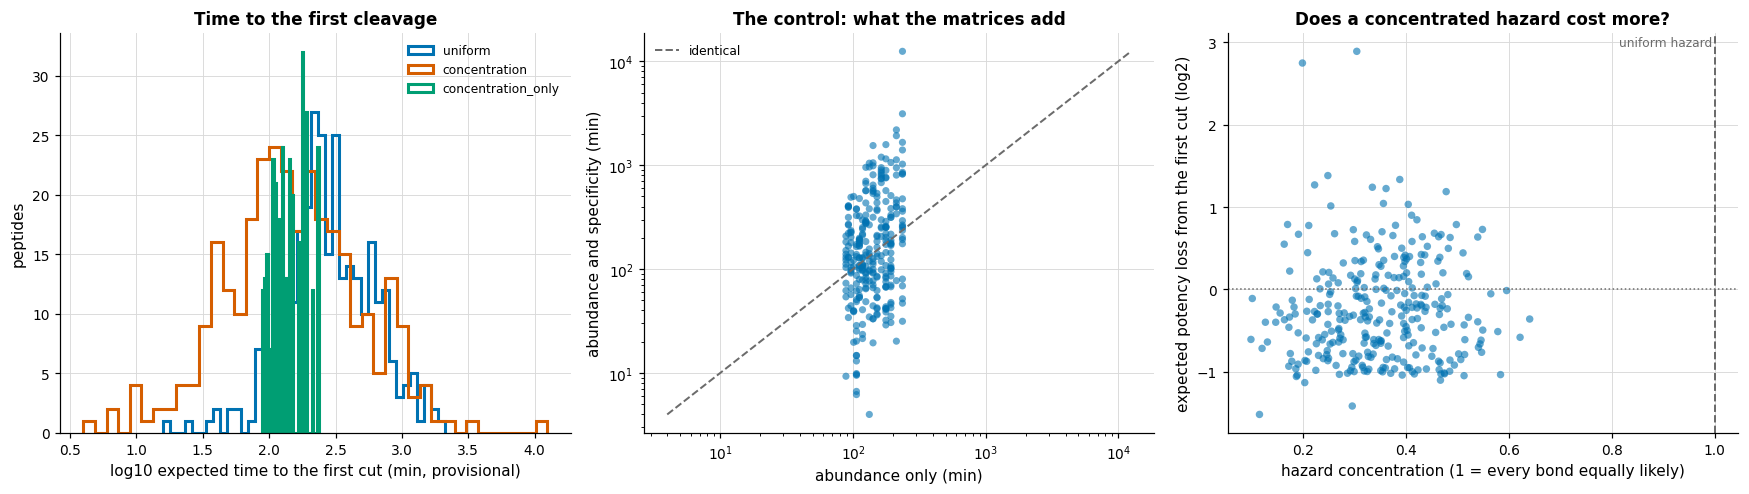

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))

ax = axes[0]
for index, name in enumerate(variants):
    subset = landscape.query("weighting == @name")
    ax.hist(
        np.log10(subset["expected_time_to_first_cut_min"]),
        bins=40,
        histtype="step",
        linewidth=2,
        color=common.CATEGORICAL_COLORS[index],
        label=name,
    )
ax.set_xlabel("log10 expected time to the first cut (min, provisional)")
ax.set_ylabel("peptides")
ax.set_title("Time to the first cleavage")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(
    wide["concentration_only"],
    wide["concentration"],
    s=22,
    alpha=0.6,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="none",
)
limits = [wide.min().min(), wide.max().max()]
ax.plot(limits, limits, color=common.NEUTRAL, linestyle="--", linewidth=1.3, label="identical")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("abundance only (min)")
ax.set_ylabel("abundance and specificity (min)")
ax.set_title("The control: what the matrices add")
ax.legend(fontsize=8)

ax = axes[2]
subset = landscape.query("weighting == 'concentration'")
ax.scatter(
    subset["hazard_concentration"],
    subset["expected_log2_potency_loss"],
    s=24,
    alpha=0.6,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="none",
)
ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.3)
ax.text(0.995, ax.get_ylim()[1] * 0.95, "uniform hazard", fontsize=8, ha="right", color=common.NEUTRAL)
ax.axhline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xlabel("hazard concentration (1 = every bond equally likely)")
ax.set_ylabel("expected potency loss from the first cut (log2)")
ax.set_title("Does a concentrated hazard cost more?")
fig.tight_layout()
plt.show()

**Provenance**

Parent sequences and reference-strain MIC values are read from `data/peptides_data/peptides_mic/peptides_apex.csv`; fragment MIC lookups come from `dbaasp_fragments_mic.csv`. Code cell 8 selects distinct DBAASP parents and maps fragment sequences to the `A. baumannii ATCC 19606` column. MEROPS *Substrate_search* 2023 matrices, `results/2_07_model_panel.csv`, and `results/3_01_time_axis_calibration.csv` supply score, protease weighting and provisional minute scale. One row of `results/4_01_single_cut_landscape.csv` is a parent peptide under one weighting; candidate bonds and proteases are summed into a first-cut hazard, while `4_01_dominant_proteases.csv` aggregates by protease. MIC values remain in the input table's MIC unit; relative potency is built from reciprocal MIC. Check code cells 6–14 for the weights, bond probabilities and fragment lookup. The original acquisition and experimental provenance of the two MIC tables are not linked from these files: TODO: provenance do ustalenia.

> **Caveat.** `results/3_01_time_axis_calibration.csv` marks the half-life rank test unvalidated. A modelled waiting time in minutes is conditional on its fitted global offset, not a measured first-cut time.


In [10]:
destination = common.save_result(landscape, "4_01_single_cut_landscape.csv")
common.save_result(dominant.reset_index(), "4_01_dominant_proteases.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
landscape.groupby("weighting").head(3).round(3)

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/4_01_single_cut_landscape.csv


,sequence,length,weighting,parent_mic,parent_potency,expected_time_to_first_cut_min,hazard_concentration,most_likely_bond,most_likely_bond_probability,dominant_protease,dominant_protease_share,expected_potency_after_cut,expected_log2_potency_loss,best_case_potency,worst_case_potency
0,FLPIVTNLLSGLL,13,uniform,97.082,1.0,889.737,0.733,2,0.195,T01.012,0.146,1.525,-0.609,1.714,1.435
1,FLPIVTNLLSGLL,13,concentration,97.082,1.0,1578.632,0.514,2,0.413,S01.217,0.352,1.526,-0.610,1.714,1.435
2,FLPIVTNLLSGLL,13,concentration_only,97.082,1.0,177.309,0.569,1,0.084,S01.217,0.699,1.538,-0.621,1.714,1.435
3,VDKPNYLPRPRPPRRIYNR,19,uniform,72.287,1.0,221.792,0.643,14,0.329,M03.001,0.170,1.245,-0.316,2.082,1.090
4,VDKPNYLPRPRPPRRIYNR,19,concentration,72.287,1.0,127.431,0.396,13,0.325,S01.217,0.531,1.161,-0.216,2.082,1.090
5,VDKPNYLPRPRPPRRIYNR,19,concentration_only,72.287,1.0,118.226,0.596,1,0.056,S01.217,0.699,1.292,-0.370,2.082,1.090
6,KIGAIKKWGAIKKIGAIK,18,uniform,36.053,1.0,253.194,0.757,11,0.149,S01.015,0.114,0.854,0.227,1.226,0.575
7,KIGAIKKWGAIKKIGAIK,18,concentration,36.053,1.0,331.772,0.517,0,0.250,S01.217,0.594,0.875,0.193,1.226,0.575
8,KIGAIKKWGAIKKIGAIK,18,concentration_only,36.053,1.0,125.178,0.592,1,0.059,S01.217,0.699,0.879,0.186,1.226,0.575
